# Laboratório 2 — Arquitetura profunda (GridVision: triagem de cena e qualidade)

Bloco profundo: **MobileNetV3-Small com duas cabeças** (cena exclusiva + defeitos multirrótulo) sobre fotos 360×480.
As fotos do cliente **não** estão no repositório: o caminho é configurável (variável `DADOS_NEOENERGIA`, ver `src/config.py`).
Rodar com *Reiniciar e executar tudo*.

In [1]:
import math, inspect, os, sys, time
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, f1_score
from sklearn.preprocessing import StandardScaler

# --- CONFIGURAÇÃO (topo): caminho das fotos e sementes ---------------------------------
# os.environ["DADOS_NEOENERGIA"] = r"C:\caminho\para\Base de Dados Neoenergia PE"
SEMENTES = [0, 1, 2]
sys.path.insert(0, str(Path.cwd() / "src"))
import triagem as T
from config import DADOS
torch.set_num_threads(4)
print("fotos lidas de:", DADOS)

fotos lidas de: C:\Users\joaop\Downloads\Base de Dados Neoenergia PE\Base de Dados Neoenergia PE


## C4 — Partição por lote (conferência)

In [2]:
rot = T.carregar_rotulos()
print(rot.groupby(["conjunto", "lote"]).size().rename("fotos").to_frame())
print(pd.crosstab(rot.conjunto, rot.cena))
print(pd.read_csv("rotulos/particao.csv").to_string(index=False))
assert rot.groupby("lote").conjunto.nunique().max() == 1, "um lote caiu em dois conjuntos"

                      fotos
conjunto  lote             
teste     2026-07-03    125
treino    2026-05-20    125
          2026-05-21    125
validacao 2026-05-22    125
cena       cena_ocorrencia  ciclometrico  digital  nao_medidor
conjunto                                                      
teste                   14            14       92            5
treino                  32            37      170           11
validacao               11            19       87            8
       universo      chave  valores_distintos  em_2_ou_mais_conjuntos
rotuladas (500) id_leitura                460                       0
rotuladas (500)    medidor                510                       0
   base inteira id_leitura              11474                       0
   base inteira    medidor              12609                       0


**Leitura (C4).** Cada lote cai em um só conjunto (treino: 05-20 e 05-21; validação: 05-22; teste: 07-03), com 500 fotos rotuladas. Nenhum id de leitura e nenhum número de medidor aparece em dois conjuntos, nem nas fotos rotuladas nem na base inteira. Classes raras continuam frágeis: `nao_medidor` tem 8 fotos na validação e 5 no teste.

## B — O modelo em código

In [3]:
print(inspect.getsource(T.ModeloTriagem)); print(inspect.getsource(T.perda_triagem))

class ModeloTriagem(nn.Module):
    """Cena é exclusiva (uma foto é de um tipo só): softmax + entropia cruzada.
    Defeitos coexistem (reflexo E fora de foco): uma sigmoide por defeito + BCE.
    A rede devolve logits; softmax e sigmoide ficam dentro das perdas e da decisão."""

    def __init__(self, pretreinado: bool = False, p_dropout: float = 0.2):
        super().__init__()
        pesos = MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretreinado else None
        base = mobilenet_v3_small(weights=pesos)
        self.extrator = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        dim = base.classifier[0].in_features  # 576
        self.cabeca_cena = nn.Sequential(nn.Dropout(p_dropout), nn.Linear(dim, len(CLASSES_CENA)))
        self.cabeca_qualidade = nn.Sequential(nn.Dropout(p_dropout), nn.Linear(dim, len(DEFEITOS)))

    def caracteristicas(self, x):
        return self.pool(self.extrator(x)).flatten(1)

    def forward(self, x):
        z = self.caracteristicas(x)
 

### B1 — Tabela de formas (entrada real: 1×3×480×360)

In [4]:
modelo = T.ModeloTriagem(pretreinado=True)
print(T.tabela_de_formas(modelo, torch.randn(1, 3, T.ALTURA, T.LARGURA)).to_string(index=False))

          camada       forma_saida
      extrator.0 (1, 16, 240, 180)
      extrator.1  (1, 16, 120, 90)
      extrator.2   (1, 24, 60, 45)
      extrator.3   (1, 24, 60, 45)
      extrator.4   (1, 40, 30, 23)
      extrator.5   (1, 40, 30, 23)
      extrator.6   (1, 40, 30, 23)
      extrator.7   (1, 48, 30, 23)
      extrator.8   (1, 48, 30, 23)
      extrator.9   (1, 96, 15, 12)
     extrator.10   (1, 96, 15, 12)
     extrator.11   (1, 96, 15, 12)
     extrator.12  (1, 576, 15, 12)
            pool    (1, 576, 1, 1)
     cabeca_cena            (1, 4)
cabeca_qualidade            (1, 5)


**Leitura (B1).** Entrada 480×360 → 15×12×576 no último bloco → *pool* global → 576 valores → duas cabeças lineares (4 e 5 saídas). Tudo sai como logit.

### B2 — Parâmetros

In [5]:
def n_params(m):
    return sum(p.numel() for p in m.parameters()), sum(p.numel() for p in m.parameters() if p.requires_grad)
linhas = []
t, tr = n_params(modelo); linhas.append(("ajuste fino (tudo treinável)", t, tr))
for p in modelo.extrator.parameters(): p.requires_grad = False
t, tr = n_params(modelo); linhas.append(("extração (extrator congelado)", t, tr))
for p in modelo.extrator.parameters(): p.requires_grad = True
tab = pd.DataFrame(linhas, columns=["configuração", "total", "treináveis"])
tab["cabeça cena"] = sum(p.numel() for p in modelo.cabeca_cena.parameters())
tab["cabeça qualidade"] = sum(p.numel() for p in modelo.cabeca_qualidade.parameters())
print(tab.to_string(index=False))

                 configuração  total  treináveis  cabeça cena  cabeça qualidade
 ajuste fino (tudo treinável) 932201      932201         2308              2885
extração (extrator congelado) 932201        5193         2308              2885


**Leitura (B2).** 932.201 parâmetros no ajuste fino; só 5.193 treináveis na extração (576·4+4 da cena e 576·5+5 da qualidade). ResNet-18 teria ~11,7 M: a MobileNetV3-Small é ~12× menor, o que importa para inferência em CPU.

### B3 — Ativação de saída e perda: provas na base

In [6]:
r = rot.copy()
r["n_defeitos"] = r[T.DEFEITOS].sum(axis=1)
print("fotos com 2+ defeitos ao mesmo tempo:", int((r.n_defeitos >= 2).sum()), "de", len(r))
print("pares de defeitos que coocorrem (nº de fotos):")
co = pd.DataFrame({a: {b: int(((r[a] == 1) & (r[b] == 1)).sum()) for b in T.DEFEITOS} for a in T.DEFEITOS})
print(co.to_string())
ex = r[r.n_defeitos >= 2].head(3)[["nome_arquivo", "cena"] + T.DEFEITOS]
print(ex.to_string(index=False))
print("cena: uma coluna, um valor por foto ->", r.cena.value_counts().to_dict())
print("defeitos em cena_ocorrencia/nao_medidor (regra v2: devem ser 0):",
      int(r[r.cena.isin(["cena_ocorrencia", "nao_medidor"])][T.DEFEITOS].sum().sum()))

fotos com 2+ defeitos ao mesmo tempo: 162 de 500
pares de defeitos que coocorrem (nº de fotos):
                 reflexo  fora_de_foco  tampa_suja  enquadramento  display_apagado
reflexo              132            66          23             28                1
fora_de_foco          66           200          81             68                5
tampa_suja            23            81         102             41                5
enquadramento         28            68          41             97                2
display_apagado        1             5           5              2               17
                                               nome_arquivo    cena  reflexo  fora_de_foco  tampa_suja  enquadramento  display_apagado
PSP_EXTRATLEITIMPL_030726_0121_20000000003353000152_000.jpg digital        0             1           0              1                0
PSP_EXTRATLEITIMPL_220526_0408_20000000002252972958_000.jpg digital        1             1           0              0                0
P

**Leitura (B3).**
- **Defeitos não são exclusivos:** 162 das 500 fotos têm 2 ou mais defeitos (ex.: `reflexo` + `fora_de_foco` em 66 fotos, `fora_de_foco` + `tampa_suja` em 81). Uma softmax obrigaria as probabilidades a somar 1 e não conseguiria dizer "reflexo **e** fora de foco". Logo: uma sigmoide por defeito e `BCEWithLogitsLoss`.
- **Cena é exclusiva por construção do esquema:** cada foto recebe uma só classe, pela ordem de decisão do `esquema.md`. Logo softmax + `CrossEntropyLoss`. Ressalva: a fronteira `digital` × `cena_ocorrencia` foi a que mais divergiu entre rotuladores na v1 (kappa 0,459); a exclusividade vem da regra de desempate, não de uma separação natural.
- A rede devolve logits; nem softmax nem sigmoide são aplicadas antes das perdas.

## Dados em memória (fotos rotuladas, resolução nativa)

In [7]:
t0 = time.time()
X = T.carregar_imagens(rot)                      # uint8 (300, 3, 480, 360)
Y_c = torch.tensor(rot.y_cena.values)
Y_q = torch.tensor(rot[T.DEFEITOS].values, dtype=torch.float32)
idx = {c: np.where(rot.conjunto.values == c)[0] for c in ["treino", "validacao", "teste"]}
print(X.shape, f"{time.time() - t0:.0f}s", {k: len(v) for k, v in idx.items()})

torch.Size([500, 3, 480, 360]) 1s {'treino': 250, 'validacao': 125, 'teste': 125}


## D1 — Perda inicial com pesos aleatórios

In [8]:
res = []
for s in SEMENTES:
    torch.manual_seed(s)
    m0 = T.ModeloTriagem(pretreinado=False).eval()
    sel = torch.tensor(idx["treino"][:64])
    with torch.no_grad():
        lc, lq = m0(T.normalizar(X[sel]))
    res.append((s, F.cross_entropy(lc, Y_c[sel]).item(), F.binary_cross_entropy_with_logits(lq, Y_q[sel]).item()))
d1 = pd.DataFrame(res, columns=["semente", "CE cena", "BCE defeitos"])
print(d1.to_string(index=False))
print(f"esperado: ln(4) = {math.log(4):.3f} para CE;  ln(2) = {math.log(2):.3f} para BCE")

 semente  CE cena  BCE defeitos
       0 1.380297      0.691292
       1 1.383272      0.688727
       2 1.384192      0.696549
esperado: ln(4) = 1.386 para CE;  ln(2) = 0.693 para BCE


**Leitura (D1).** CE inicial 1,380–1,384 contra ln 4 = 1,386; BCE 0,689–0,697 contra ln 2 = 0,693. Dentro do esperado: sem viés inicial nas cabeças.

## D2 — Sobreajuste de um lote de 16 fotos reais

passo   0: perda = 2.0554


passo   9: perda = 0.2474


passo  19: perda = 0.0547


passo  39: perda = 0.0060


passo  59: perda = 0.0026


passo  79: perda = 0.0018


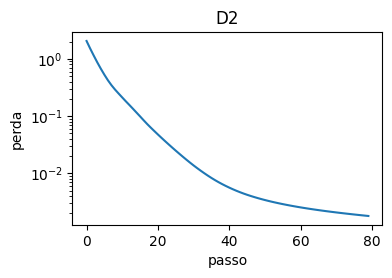

acerto de cena no lote (modo eval): 0.9375


In [9]:
torch.manual_seed(0)
m2 = T.ModeloTriagem(pretreinado=True, p_dropout=0.0)
sel = torch.tensor(idx["treino"][:16])
xb, yc, yq = T.normalizar(X[sel]), Y_c[sel], Y_q[sel]
opt = torch.optim.Adam(m2.parameters(), lr=1e-3)
m2.train()
hist = []
for i in range(80):
    opt.zero_grad()
    perda = T.perda_triagem(*m2(xb), yc, yq)
    perda.backward(); opt.step(); hist.append(perda.item())
    if i in (0, 9, 19, 39, 59, 79): print(f"passo {i:>3}: perda = {hist[-1]:.4f}")
plt.figure(figsize=(4, 2.5)); plt.semilogy(hist); plt.xlabel("passo"); plt.ylabel("perda"); plt.title("D2"); plt.show()
m2.eval()
with torch.no_grad():
    lc, lq = m2(xb)
print("acerto de cena no lote (modo eval):", (lc.argmax(-1) == yc).float().mean().item())
assert hist[-1] < 0.1, "não decorou 16 fotos: defeito no modelo, na perda ou nos rótulos"

**Leitura (D2).** 16 fotos reais, sem dropout, ajuste fino completo: a perda vai de 2,06 a 0,0018 em 80 passos. Passou. O acerto de cena em modo `eval` é 15/16: com lote de 16 a *BatchNorm* treina com estatística do lote e, em `eval`, usa a média móvel, que ainda não convergiu em 80 passos. Explicação provável, não testada aqui.

## D3 — Extração de características × baselines não profundas (mesma validação, mesma métrica)

In [10]:
modelo = T.ModeloTriagem(pretreinado=True)
t0 = time.time()
Z = T.extrair(modelo, X)                          # (300, 576), extrator congelado, sem aumento
V0 = T.v0_caracteristicas(X)                      # (300, 22)
print("Z", tuple(Z.shape), "V0", V0.shape, f"{time.time() - t0:.0f}s")

def treinar_cabecas(semente, epocas=300, lr=1e-3, wd=1e-3):
    # Equivale a treinar o ModeloTriagem com o extrator congelado: o extrator é determinístico (modo eval),
    # então as características Z são calculadas uma vez. Hiperparâmetros fixos, não escolhidos na validação.
    torch.manual_seed(semente)
    m = T.ModeloTriagem(pretreinado=True)
    ps = list(m.cabeca_cena.parameters()) + list(m.cabeca_qualidade.parameters())
    opt = torch.optim.Adam(ps, lr=lr, weight_decay=wd)
    tr = torch.tensor(idx["treino"])
    for _ in range(epocas):
        m.cabeca_cena.train(); m.cabeca_qualidade.train()
        opt.zero_grad()
        perda = T.perda_triagem(m.cabeca_cena(Z[tr]), m.cabeca_qualidade(Z[tr]), Y_c[tr], Y_q[tr])
        perda.backward(); opt.step()
    m.eval()
    return m

def logits(m, conj):
    with torch.no_grad():
        j = torch.tensor(idx[conj])
        return m.cabeca_cena(Z[j]), m.cabeca_qualidade(Z[j])

def metricas(p_cena, p_def, conj):
    j = idx[conj]
    yc, yq = Y_c[j].numpy(), Y_q[j].numpy()
    f1 = f1_score(yc, p_cena.argmax(1), average="macro", labels=range(4), zero_division=0)
    acc = accuracy_score(yc, p_cena.argmax(1))
    aps = {d: average_precision_score(yq[:, k], p_def[:, k]) for k, d in enumerate(T.DEFEITOS) if yq[:, k].sum() > 0}
    return dict(F1_cena=f1, acc_cena=acc, AP_defeitos=np.mean(list(aps.values())), **{f"AP_{d}": v for d, v in aps.items()})

modelos = {s: treinar_cabecas(s) for s in SEMENTES}
saida = {}   # nome -> conjunto -> lista de dicts (um por semente)
saida["MobileNetV3 (extração)"] = {
    c: [metricas(F.softmax(logits(modelos[s], c)[0], -1).numpy(), logits(modelos[s], c)[1].sigmoid().numpy(), c)
        for s in SEMENTES] for c in ["validacao", "teste"]}

def baseline(F_, nome, C=1.0):
    sc = StandardScaler().fit(F_[idx["treino"]])
    f = lambda c: sc.transform(F_[idx[c]])
    clf = LogisticRegression(C=C, max_iter=5000, class_weight="balanced").fit(f("treino"), Y_c[idx["treino"]].numpy())
    pc = {}
    pd_ = {c: np.zeros((len(idx[c]), 5)) for c in ["validacao", "teste"]}
    for c in pd_:
        a = np.zeros((len(idx[c]), 4)); a[:, clf.classes_] = clf.predict_proba(f(c)); pc[c] = a
    for k in range(5):
        y = Y_q[idx["treino"], k].numpy()
        if y.sum() == 0: continue
        cl = LogisticRegression(C=C, max_iter=5000, class_weight="balanced").fit(f("treino"), y)
        for c in pd_: pd_[c][:, k] = cl.predict_proba(f(c))[:, 1]
    saida[nome] = {c: [metricas(pc[c], pd_[c], c)] for c in pc}
    return pc, pd_

pc_v0, pd_v0 = baseline(V0.astype(np.float64), "V0 heurística + regressão logística")
pc_lr, pd_lr = baseline(Z.numpy().astype(np.float64), "características profundas + regressão logística", C=0.1)

linhas = []
for nome, por_conj in saida.items():
    for c, lst in por_conj.items():
        df = pd.DataFrame(lst)
        linhas.append({"método": nome, "conjunto": c, **{k: f"{df[k].mean():.3f}" + (f" ± {df[k].std():.3f}" if len(df) > 1 else "")
                       for k in ["F1_cena", "acc_cena", "AP_defeitos"]}})
print(pd.DataFrame(linhas).to_string(index=False))
print()
print("AP por defeito, validação (média das sementes no modelo profundo):")
pv = pd.DataFrame({nome: pd.DataFrame(por["validacao"]).filter(like="AP_").drop(columns="AP_defeitos").mean() for nome, por in saida.items()})
print(pv.round(3).to_string())
print("positivos na validação:", {d: int(Y_q[idx['validacao'], k].sum()) for k, d in enumerate(T.DEFEITOS)})
print("positivos no teste    :", {d: int(Y_q[idx['teste'], k].sum()) for k, d in enumerate(T.DEFEITOS)})

Z (500, 576) V0 (500, 22) 6s


                                         método  conjunto       F1_cena      acc_cena   AP_defeitos
                         MobileNetV3 (extração) validacao 0.550 ± 0.005 0.773 ± 0.005 0.509 ± 0.004
                         MobileNetV3 (extração)     teste 0.602 ± 0.020 0.797 ± 0.012 0.607 ± 0.002
            V0 heurística + regressão logística validacao         0.281         0.392         0.360
            V0 heurística + regressão logística     teste         0.293         0.432         0.425
características profundas + regressão logística validacao         0.647         0.776         0.498
características profundas + regressão logística     teste         0.657         0.816         0.561

AP por defeito, validação (média das sementes no modelo profundo):
                    MobileNetV3 (extração)  V0 heurística + regressão logística  características profundas + regressão logística
AP_reflexo                           0.504                                0.265                        

**Leitura (D3).** Extração de características (extrator congelado, só as cabeças treinam; 3 sementes), mesma partição e métricas das baselines. Hiperparâmetros fixos, nenhum escolhido na validação.
- **Profundo × V0 (Laplaciano, brilho, histograma):** o profundo ganha com folga nos dois conjuntos. Validação: F1 macro da cena 0,550 contra 0,281; AP médio dos defeitos 0,509 contra 0,360. Teste: 0,602 contra 0,293 e 0,607 contra 0,425.
- **Profundo × regressão logística sobre as mesmas características profundas:** a regressão logística (um só ajuste, sem desvio entre sementes) fica **acima na cena** (F1 0,647 contra 0,550 na validação; 0,657 contra 0,602 no teste) e **abaixo nos defeitos** (AP 0,498 contra 0,509 na validação; 0,561 contra 0,607 no teste). Não há vencedor claro: a cabeça treinada por gradiente não supera um modelo linear simples sobre as mesmas características na cena.
- **Cuidado com o tamanho:** a validação e o teste têm 125 fotos cada. `display_apagado` tem 5 positivos na validação e 6 no teste (17 em toda a amostra): o AP dele (0,047 na validação) é do tamanho da prevalência (5/125 = 0,04), ou seja, não é melhor que o acaso. O F1 macro da cena pesa `nao_medidor` (8 fotos na validação, 5 no teste).
- Não medido aqui: aumento de dados na extração, `pos_weight` para as classes raras.

## E1 — Calibração: diagrama de confiabilidade, ECE e *temperature scaling* (ajustada na validação)

 semente     T  ECE val antes  ECE val depois  NLL val antes  NLL val depois  ECE teste antes  ECE teste depois  NLL teste antes  NLL teste depois
       0 1.037          0.056           0.053          0.555           0.555            0.040             0.058            0.501             0.501
       1 1.041          0.078           0.043          0.546           0.546            0.036             0.032            0.483             0.484
       2 1.046          0.043           0.035          0.536           0.536            0.034             0.028            0.491             0.491
média: {'T': 1.041, 'ECE val antes': 0.059, 'ECE val depois': 0.044, 'NLL val antes': 0.546, 'NLL val depois': 0.546, 'ECE teste antes': 0.037, 'ECE teste depois': 0.039, 'NLL teste antes': 0.492, 'NLL teste depois': 0.492}


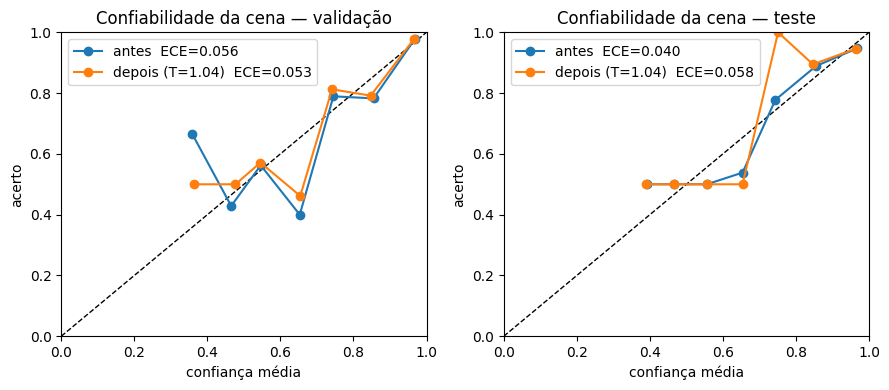

In [11]:
def ece(prob, acerto, bins=10):
    prob, acerto = np.asarray(prob), np.asarray(acerto, dtype=float)
    lim = np.linspace(0, 1, bins + 1); e = 0.0; pts = []
    for lo, hi in zip(lim[:-1], lim[1:]):
        m = (prob > lo) & (prob <= hi)
        if m.any():
            e += m.mean() * abs(acerto[m].mean() - prob[m].mean()); pts.append((prob[m].mean(), acerto[m].mean(), m.sum()))
    return e, pts

def ajustar_temperatura(lg, y):
    logT = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([logT], lr=0.1, max_iter=200)
    def f():
        opt.zero_grad(); l = F.cross_entropy(lg / logT.exp(), y); l.backward(); return l
    opt.step(f)
    return logT.exp().item()

def ece_cena(lg, y, T_=1.0):
    p = F.softmax(lg / T_, -1); conf, pred = p.max(-1)
    return ece(conf.numpy(), (pred == y).numpy())

linhas, graf = [], None
for s in SEMENTES:
    lv, _ = logits(modelos[s], "validacao"); lt, _ = logits(modelos[s], "teste")
    yv, yt = Y_c[idx["validacao"]], Y_c[idx["teste"]]
    Tm = ajustar_temperatura(lv, yv)
    r_ = dict(semente=s, T=Tm)
    for nome, lg, y in [("val", lv, yv), ("teste", lt, yt)]:
        r_[f"ECE {nome} antes"] = ece_cena(lg, y)[0]; r_[f"ECE {nome} depois"] = ece_cena(lg, y, Tm)[0]
        r_[f"NLL {nome} antes"] = F.cross_entropy(lg, y).item(); r_[f"NLL {nome} depois"] = F.cross_entropy(lg / Tm, y).item()
    linhas.append(r_)
    if s == SEMENTES[0]: graf = (lv, lt, yv, yt, Tm)
tab = pd.DataFrame(linhas); print(tab.round(3).to_string(index=False))
print("média:", tab.drop(columns="semente").mean().round(3).to_dict())

lv, lt, yv, yt, Tm = graf
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, (nome, lg, y) in zip(ax, [("validação", lv, yv), ("teste", lt, yt)]):
    a.plot([0, 1], [0, 1], "k--", lw=1)
    for rot_, T_ in [("antes", 1.0), (f"depois (T={Tm:.2f})", Tm)]:
        e, pts = ece_cena(lg, y, T_)
        if pts:
            p_ = np.array(pts); a.plot(p_[:, 0], p_[:, 1], "o-", label=f"{rot_}  ECE={e:.3f}")
    a.set_title(f"Confiabilidade da cena — {nome}"); a.set_xlabel("confiança média"); a.set_ylabel("acerto"); a.legend(); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Leitura (E1).** A temperatura ajustada na validação é ≈ 1,04 (1,04–1,05): o modelo já sai praticamente calibrado. O *temperature scaling* melhora um pouco o ECE na validação (0,059 → 0,044 em média, onde a temperatura foi ajustada) e não muda no teste (0,037 → 0,039); a NLL não se altera. Com 125 fotos e 10 faixas, o ECE varia vários centésimos entre sementes (0,043–0,078 antes), então a diferença é da ordem do ruído. Resultado honesto: a calibração quase não ajuda, porque não há descalibração grande a corrigir. Diagrama e ECE são da cena; os defeitos não foram calibrados.

## E2 — Cobertura × risco (abstenção por confiança da cena)

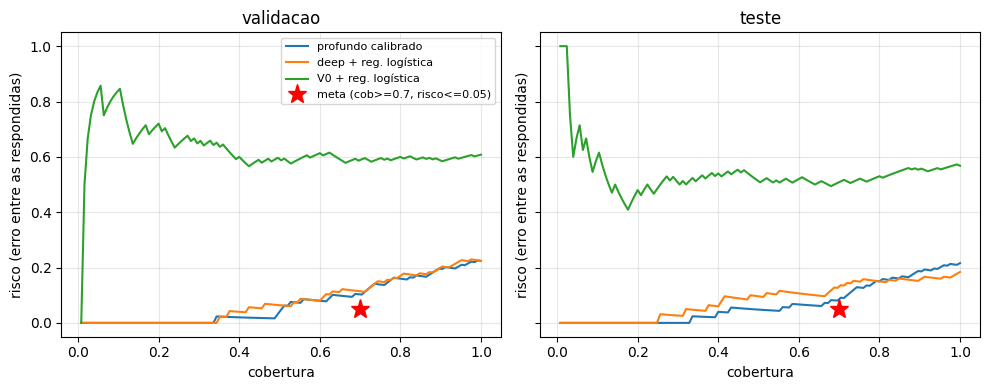

               método   tau  cob_val  risco_val  cob_teste  risco_teste  atinge_meta_val  maior_cob_com_risco<=meta (val)
   profundo calibrado 0.695    0.704      0.102      0.656        0.061            False                            0.504
deep + reg. logística 0.774    0.704      0.114      0.768        0.156            False                            0.416
  V0 + reg. logística 0.428    0.704      0.591      0.744        0.516            False                            0.008


In [12]:
# META declarada pelo grupo (hipótese a validar com a Neoenergia; o SR1 deixa em aberto a taxa aceita para dispensar a revisão):
# "cobertura >= 70% com risco <= 5%"
META_COBERTURA, META_RISCO = 0.70, 0.05

def curva(conf, acerto):
    o = np.argsort(-conf); c = np.asarray(acerto, dtype=float)[o]
    n = np.arange(1, len(c) + 1)
    return n / len(c), 1 - np.cumsum(c) / n, conf[o]      # cobertura, risco, confiança do último aceito

def conf_acerto(P_, conj):
    return P_.max(1), (P_.argmax(1) == Y_c[idx[conj]].numpy())

P = {}
for c in ["validacao", "teste"]:
    lg, _ = logits(modelos[SEMENTES[0]], c)
    P[("profundo calibrado", c)] = F.softmax(lg / Tm, -1).numpy()
    P[("deep + reg. logística", c)] = pc_lr[c]
    P[("V0 + reg. logística", c)] = pc_v0[c]
METODOS = ["profundo calibrado", "deep + reg. logística", "V0 + reg. logística"]

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for a, c in zip(ax, ["validacao", "teste"]):
    for nome in METODOS:
        cob, risco, _ = curva(*conf_acerto(P[(nome, c)], c)); a.plot(cob, risco, label=nome)
    a.plot(META_COBERTURA, META_RISCO, "r*", ms=14, label=f"meta (cob>={META_COBERTURA}, risco<={META_RISCO})")
    a.set_title(c); a.set_xlabel("cobertura"); a.set_ylabel("risco (erro entre as respondidas)"); a.grid(alpha=.3)
ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()

# Limiar escolhido SÓ na validação (o de maior confiança que ainda dá cobertura >= meta); aplicado ao teste uma vez.
linhas = []
for nome in METODOS:
    cob, risco, lim = curva(*conf_acerto(P[(nome, "validacao")], "validacao"))
    ok = np.where(cob >= META_COBERTURA)[0]
    row = dict(método=nome)
    if len(ok):
        tau = lim[ok[0]]
        ct, at = conf_acerto(P[(nome, "teste")], "teste"); m = ct >= tau
        row.update(tau=round(float(tau), 3), cob_val=round(float(cob[ok[0]]), 3), risco_val=round(float(risco[ok[0]]), 3),
                   cob_teste=round(float(m.mean()), 3), risco_teste=round(float(1 - at[m].mean()), 3) if m.any() else None,
                   atinge_meta_val=bool(risco[ok[0]] <= META_RISCO))
    ok_r = np.where(risco <= META_RISCO)[0]
    row["maior_cob_com_risco<=meta (val)"] = round(float(cob[ok_r[-1]]), 3) if len(ok_r) else 0.0
    linhas.append(row)
print(pd.DataFrame(linhas).to_string(index=False))

**Leitura (E2).** O risco é o erro de **cena** entre as fotos respondidas (a decisão ACEITA/REJEITADA/DUVIDA do esqueleto, que também usa os defeitos, não foi avaliada). A meta é uma **hipótese do grupo**, a validar com a Neoenergia (o SR1 deixa em aberto a taxa aceita para dispensar a revisão): cobertura ≥ 70% com risco ≤ 5%. Limiar fixado na validação e aplicado uma vez ao teste.
- **Modelo profundo calibrado:** cobertura 0,70 com risco 0,102 na validação. No teste, o mesmo limiar dá cobertura 0,66 e risco 0,061. A meta **não é atingida** na validação, e no teste fica perto, mas com cobertura abaixo. Na validação, risco ≤ 0,05 só até cobertura 0,50.
- **Regressão logística sobre características profundas:** risco 0,114 na validação e 0,156 no teste (risco ≤ 0,05 até cobertura 0,42). **V0:** risco ~0,59 (praticamente nada).
- Para fechar a meta, é preciso mais rótulos, ou aceitar cobertura ~50% com risco ≤ 5%, ou risco ~10% com cobertura 70%. A escolha é do negócio.

## F — Ajuste fino (extrator descongelado) e curva de dados

Ajuste fino a partir das cabeças já treinadas na extração (*linear probe* e depois ajuste fino). Aumento de dados **sem** desfoque sintético
(o desfoque é o que `fora_de_foco` precisa detectar) e **sem** espelhamento horizontal (dígitos). Agenda fixa de 12 épocas,
nenhuma escolha feita no teste.

semente 0: 144s  perda treino 1.075 -> 0.482;  F1 val 0.437 -> 0.590


semente 1: 279s  perda treino 1.122 -> 0.457;  F1 val 0.538 -> 0.577


semente 2: 417s  perda treino 1.100 -> 0.464;  F1 val 0.546 -> 0.608


                   método  conjunto       F1_cena      acc_cena   AP_defeitos
   MobileNetV3 (extração) validacao 0.550 ± 0.005 0.773 ± 0.005 0.509 ± 0.004
   MobileNetV3 (extração)     teste 0.602 ± 0.020 0.797 ± 0.012 0.607 ± 0.002
MobileNetV3 (ajuste fino) validacao 0.592 ± 0.016 0.800 ± 0.008 0.524 ± 0.001
MobileNetV3 (ajuste fino)     teste 0.545 ± 0.056 0.808 ± 0.008 0.609 ± 0.005
AP por defeito, validação:
                    MobileNetV3 (extração)  MobileNetV3 (ajuste fino)
AP_reflexo                           0.504                      0.481
AP_fora_de_foco                      0.781                      0.818
AP_tampa_suja                        0.733                      0.766
AP_enquadramento                     0.478                      0.496
AP_display_apagado                   0.047                      0.059


 semente     T  ECE_val_antes  ECE_val_depois  ECE_teste_antes  ECE_teste_depois
       0 1.391          0.092           0.072            0.072             0.040
       1 1.347          0.061           0.074            0.084             0.056
       2 1.366          0.072           0.054            0.062             0.042


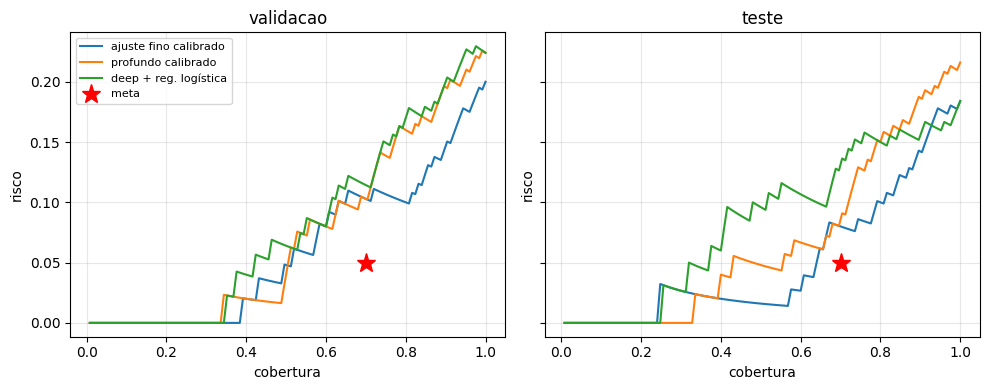

               método   tau  cob_val  risco_val  cob_teste  risco_teste  maior_cob_risco_meta_val
ajuste fino calibrado 0.721    0.704      0.102      0.744        0.086                     0.512
   profundo calibrado 0.695    0.704      0.102      0.656        0.061                     0.504


In [13]:
from torchvision.transforms import v2
import copy
AUMENTO = v2.Compose([v2.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.9, 1.1)),
                      v2.ColorJitter(brightness=0.2, contrast=0.2)])

def ajuste_fino(semente, epocas=12, lote=16, lr_base=1e-4, lr_cab=1e-3, wd=1e-2):
    torch.manual_seed(semente); np.random.seed(semente)
    m = copy.deepcopy(modelos[semente])                   # extrator pré-treinado + cabeças da extração
    for p in m.parameters(): p.requires_grad = True
    cabecas = list(m.cabeca_cena.parameters()) + list(m.cabeca_qualidade.parameters())
    ids_cab = {id(p) for p in cabecas}
    base = [p for p in m.parameters() if id(p) not in ids_cab]
    opt = torch.optim.AdamW([{"params": base, "lr": lr_base}, {"params": cabecas, "lr": lr_cab}], weight_decay=wd)
    tr = idx["treino"]; passos = epocas * math.ceil(len(tr) / lote)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[lr_base, lr_cab], total_steps=passos, pct_start=0.2)
    hist = []
    for ep in range(epocas):
        m.train()
        perm = np.random.permutation(tr); soma = 0.0
        for i in range(0, len(perm), lote):
            j = perm[i:i + lote]
            xb = torch.stack([AUMENTO(X[k]) for k in j])
            opt.zero_grad()
            perda = T.perda_triagem(*m(T.normalizar(xb)), Y_c[j], Y_q[j])
            perda.backward(); opt.step(); sched.step(); soma += perda.item() * len(j)
        m.eval()
        with torch.no_grad():
            lv = m(T.normalizar(X[idx["validacao"]]))
        pv_ = F.softmax(lv[0], -1).numpy()
        hist.append((ep + 1, soma / len(tr), f1_score(Y_c[idx["validacao"]].numpy(), pv_.argmax(1), average="macro", labels=range(4), zero_division=0)))
    return m, hist

@torch.no_grad()
def logits_modelo(m, conj, lote=32):
    m.eval(); j = idx[conj]
    out = [m(T.normalizar(X[j[i:i + lote]])) for i in range(0, len(j), lote)]
    return torch.cat([o[0] for o in out]), torch.cat([o[1] for o in out])

t0 = time.time()
ft, hist_ft = {}, {}
for s in SEMENTES:
    ft[s], hist_ft[s] = ajuste_fino(s)
    print(f"semente {s}: {time.time() - t0:.0f}s  perda treino {hist_ft[s][0][1]:.3f} -> {hist_ft[s][-1][1]:.3f};  F1 val {hist_ft[s][0][2]:.3f} -> {hist_ft[s][-1][2]:.3f}")

saida["MobileNetV3 (ajuste fino)"] = {c: [metricas(F.softmax(logits_modelo(ft[s], c)[0], -1).numpy(), logits_modelo(ft[s], c)[1].sigmoid().numpy(), c) for s in SEMENTES]
                                       for c in ["validacao", "teste"]}
linhas = []
for nome in ["MobileNetV3 (extração)", "MobileNetV3 (ajuste fino)"]:
    for c, lst in saida[nome].items():
        df = pd.DataFrame(lst)
        linhas.append({"método": nome, "conjunto": c, **{k: f"{df[k].mean():.3f} ± {df[k].std():.3f}" for k in ["F1_cena", "acc_cena", "AP_defeitos"]}})
print(pd.DataFrame(linhas).to_string(index=False))
print("AP por defeito, validação:")
print(pd.DataFrame({n: pd.DataFrame(saida[n]["validacao"]).filter(like="AP_").drop(columns="AP_defeitos").mean() for n in ["MobileNetV3 (extração)", "MobileNetV3 (ajuste fino)"]}).round(3).to_string())

# calibração (T ajustada na validação) e cobertura × risco do modelo ajustado, mesmos moldes de E1/E2
res = []
for s in SEMENTES:
    lv, _ = logits_modelo(ft[s], "validacao"); lt, _ = logits_modelo(ft[s], "teste")
    Tf = ajustar_temperatura(lv, Y_c[idx["validacao"]])
    res.append(dict(semente=s, T=Tf, ECE_val_antes=ece_cena(lv, Y_c[idx["validacao"]])[0], ECE_val_depois=ece_cena(lv, Y_c[idx["validacao"]], Tf)[0],
                    ECE_teste_antes=ece_cena(lt, Y_c[idx["teste"]])[0], ECE_teste_depois=ece_cena(lt, Y_c[idx["teste"]], Tf)[0]))
print(pd.DataFrame(res).round(3).to_string(index=False))
Tf0 = res[0]["T"]
for c in ["validacao", "teste"]:
    P[("ajuste fino calibrado", c)] = F.softmax(logits_modelo(ft[SEMENTES[0]], c)[0] / Tf0, -1).numpy()
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for a, c in zip(ax, ["validacao", "teste"]):
    for nome in ["ajuste fino calibrado", "profundo calibrado", "deep + reg. logística"]:
        cob, risco, _ = curva(*conf_acerto(P[(nome, c)], c)); a.plot(cob, risco, label=nome)
    a.plot(META_COBERTURA, META_RISCO, "r*", ms=14, label="meta"); a.set_title(c); a.set_xlabel("cobertura"); a.set_ylabel("risco"); a.grid(alpha=.3)
ax[0].legend(fontsize=8); plt.tight_layout(); plt.show()
linhas = []
for nome in ["ajuste fino calibrado", "profundo calibrado"]:
    cob, risco, lim = curva(*conf_acerto(P[(nome, "validacao")], "validacao"))
    ok = np.where(cob >= META_COBERTURA)[0][0]; tau = lim[ok]
    ct, at = conf_acerto(P[(nome, "teste")], "teste"); m_ = ct >= tau
    ok_r = np.where(risco <= META_RISCO)[0]
    linhas.append(dict(método=nome, tau=round(float(tau), 3), cob_val=round(float(cob[ok]), 3), risco_val=round(float(risco[ok]), 3),
                       cob_teste=round(float(m_.mean()), 3), risco_teste=round(float(1 - at[m_].mean()), 3),
                       maior_cob_risco_meta_val=round(float(cob[ok_r[-1]]), 3) if len(ok_r) else 0.0))
print(pd.DataFrame(linhas).to_string(index=False))

**Leitura (F, ajuste fino).** 12 épocas, 3 sementes, agenda fixa, nada escolhido no teste. O ajuste fino fica **dentro do ruído** da extração e muda de sinal entre validação e teste: F1 da cena 0,592 ± 0,016 contra 0,550 na validação, mas 0,545 ± 0,056 contra 0,602 no teste; AP dos defeitos 0,524 contra 0,509 na validação e 0,609 contra 0,607 no teste. Na cobertura × risco, o risco na validação é o mesmo (0,102 nos dois) e o limiar cai em coberturas diferentes no teste (0,74 contra 0,66), o que impede comparar o risco do teste. A temperatura sobe para ~1,35–1,39: o ajuste fino deixa o modelo supraconfiante, e o *temperature scaling* melhora o ECE em 5 de 6 casos (3 sementes × validação e teste; ex.: teste 0,072 → 0,040). Conclusão: o ajuste fino custa ~140 s por semente na CPU, contra segundos da extração, e não traz ganho consistente com 250 fotos de treino.

         F1_cena        AP_defeitos        risco_cob70       
            mean    std        mean    std        mean    std
n_treino                                                     
62         0.376  0.110       0.434  0.005       0.174  0.017
125        0.467  0.103       0.467  0.025       0.159  0.011
188        0.530  0.013       0.496  0.014       0.125  0.011
250        0.546  0.011       0.510  0.004       0.098  0.007


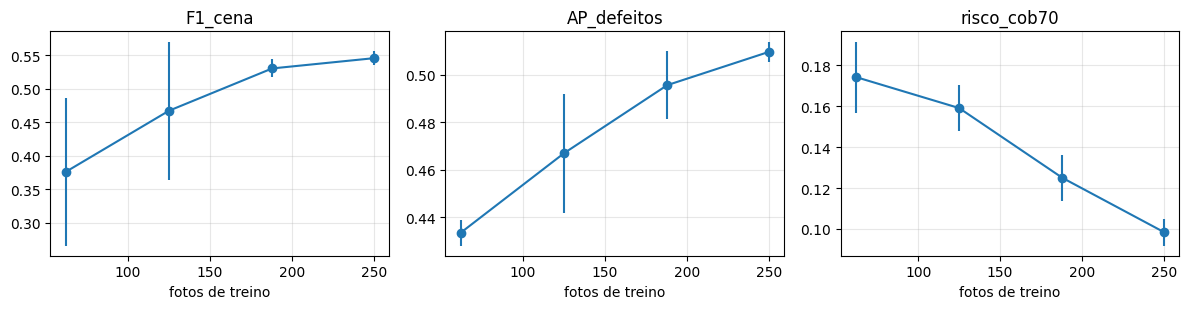

In [14]:
# Curva de dados (bônus): métrica na validação × nº de fotos de treino (subconjuntos aninhados por semente; extração de características).
def risco_em_cobertura(P_, conj, cob_alvo):
    cob, risco, _ = curva(*conf_acerto(P_, conj))
    return float(risco[np.where(cob >= cob_alvo)[0][0]])

linhas = []
tr_all = idx["treino"]
for s in SEMENTES:
    ordem = np.random.RandomState(s).permutation(tr_all)
    for n in [int(round(len(tr_all) * f_)) for f_ in (0.25, 0.5, 0.75, 1.0)]:
        sub = ordem[:n]
        torch.manual_seed(s)
        m = T.ModeloTriagem(pretreinado=True)
        ps = list(m.cabeca_cena.parameters()) + list(m.cabeca_qualidade.parameters())
        opt = torch.optim.Adam(ps, lr=1e-3, weight_decay=1e-3)
        for _ in range(300):
            m.cabeca_cena.train(); m.cabeca_qualidade.train(); opt.zero_grad()
            T.perda_triagem(m.cabeca_cena(Z[sub]), m.cabeca_qualidade(Z[sub]), Y_c[sub], Y_q[sub]).backward(); opt.step()
        m.eval()
        with torch.no_grad():
            j = torch.tensor(idx["validacao"]); lc, lq = m.cabeca_cena(Z[j]), m.cabeca_qualidade(Z[j])
        pcv = F.softmax(lc, -1).numpy()
        mt = metricas(pcv, lq.sigmoid().numpy(), "validacao")
        linhas.append(dict(semente=s, n_treino=n, F1_cena=mt["F1_cena"], AP_defeitos=mt["AP_defeitos"], risco_cob70=risco_em_cobertura(pcv, "validacao", META_COBERTURA)))
dc = pd.DataFrame(linhas)
resumo = dc.groupby("n_treino")[["F1_cena", "AP_defeitos", "risco_cob70"]].agg(["mean", "std"]).round(3)
print(resumo.to_string())
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for a, k in zip(ax, ["F1_cena", "AP_defeitos", "risco_cob70"]):
    g = dc.groupby("n_treino")[k]; a.errorbar(g.mean().index, g.mean(), yerr=g.std(), marker="o"); a.set_title(k); a.set_xlabel("fotos de treino"); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Leitura (curva de dados).** Extração de características, subconjuntos aninhados do treino (25%, 50%, 75% e 100% de 250 fotos), 3 sementes. As métricas melhoram com mais dados: F1 da cena 0,376 → 0,467 → 0,530 → 0,546; AP dos defeitos 0,434 → 0,467 → 0,496 → 0,510; risco na cobertura de 70% 0,174 → 0,159 → 0,125 → 0,098. O F1 já desacelera no último passo (+0,016), enquanto o risco ainda cai (−0,027). Esta curva usa a validação de 125 fotos e **não é comparável** com a anterior (150 fotos de treino e validação de 75). Estimativa por extrapolação linear (não medida, e curvas tendem a achatar): risco ≤ 0,05 pediria da ordem de 100 fotos de treino a mais.